# 01 — Baseline Forecasting (WRMSSE + FVA ladder)

Establishes the accuracy bar before any deep learning. It trains a ladder of
increasingly capable forecasters on the preprocessed panel — naive, seasonal
naive, a global linear (Ridge) model, and a global gradient-boosted model
(LightGBM with a Tweedie objective for intermittent count demand) — and scores
every tier on the **official M5 WRMSSE** over all 12 aggregation levels plus point
metrics (WAPE, RMSE, BIAS) on a 28-day time-based holdout.

A **Forecast Value Added (FVA)** ladder shows which tiers actually earn their
complexity. Per-series WRMSSE is exported for the segmentation notebook, and the
GBM point forecast is exported as the baseline the neural quantile model (notebook
02) must beat.

**Input:** `data/panel.parquet`  **Outputs:** `data/series_scores.parquet`,
`data/baseline_forecast.parquet`

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
from sklearn.linear_model import Ridge

ROOT = Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import metrics as M
sns.set_style("whitegrid"); plt.rcParams.update({"figure.dpi":110,"figure.figsize":(10,5)})

HORIZON = 28
panel = pd.read_parquet(ROOT/"data"/"panel.parquet")
panel["date"] = pd.to_datetime(panel["date"])
print("panel:", panel.shape, "| series:", panel["series_id"].nunique())

panel: (12380000, 47) | series: 10000


Split into train and a final 28-day holdout, time-based and shared by every tier.

In [2]:
cutoff = panel["date"].max() - pd.Timedelta(days=HORIZON-1)
train = panel[panel["date"] < cutoff].copy()
valid = panel[panel["date"] >= cutoff].copy()
id_cols = ["item_id","dept_id","cat_id","store_id","state_id"]
print("train:", train["date"].min().date(),"→",train["date"].max().date(), train.shape)
print("valid:", valid["date"].min().date(),"→",valid["date"].max().date(), valid.shape)
evaluator = M.WRMSSEEvaluator(train, valid)
results, preds = {}, {}

train: 2013-01-01 → 2016-04-24 (12100000, 47)
valid: 2016-04-25 → 2016-05-22 (280000, 47)


Helper that records WRMSSE and point metrics for a tier given its prediction frame.

In [3]:
def score_tier(name, pred_units):
    p = valid[["item_id","dept_id","cat_id","store_id","state_id","date","series_id"]].copy()
    p["pred"] = np.clip(np.asarray(pred_units, float), 0, None)
    wr = evaluator.score(p)
    pm = M.point_metrics(valid["units"].values, p["pred"].values)
    results[name] = {"WRMSSE": wr["WRMSSE"], **pm}
    preds[name] = p
    print(f"{name:20s} WRMSSE={wr['WRMSSE']:.4f}  WAPE={pm['WAPE']:.4f}  RMSE={pm['RMSE']:.3f}")
    return p

**L0 Naive** — carry each series' last training value across the whole holdout.

In [4]:
last = train.sort_values("date").groupby("series_id")["units"].last()
score_tier("L0_Naive", valid["series_id"].map(last).values);

L0_Naive             WRMSSE=1.2977  WAPE=0.8122  RMSE=4.686


**L1 Seasonal Naive** — use the value from the same weekday one week earlier (lag-7).

In [5]:
both = pd.concat([train, valid]).sort_values(["series_id","date"])
both["lag7"] = both.groupby("series_id")["units"].shift(7)
v = valid.merge(both[["series_id","date","lag7"]], on=["series_id","date"], how="left")
score_tier("L1_SeasonalNaive", v["lag7"].fillna(v["lag7"].mean()).values);

L1_SeasonalNaive     WRMSSE=0.8588  WAPE=0.7295  RMSE=4.324


**L2 Ridge** — a single global linear model on lag, calendar, and price features.

In [6]:
feat_lin = ["lag_1","lag_7","lag_14","lag_28","rmean_7","rmean_28",
            "is_weekend","snap","on_promo","price_ratio"]
Xtr = train[feat_lin].fillna(0).values; ytr = train["units"].values
ridge = Ridge(alpha=1.0).fit(Xtr, ytr)
score_tier("L2_Ridge", ridge.predict(valid[feat_lin].fillna(0).values));

L2_Ridge             WRMSSE=0.6688  WAPE=0.6001  RMSE=3.415


**L4 LightGBM** — a global gradient-boosted model with a Tweedie objective suited to intermittent count demand, with an inner time-based early-stopping split.

In [7]:
feat_gbm = ["day_of_week","is_weekend","day_of_month","week_of_year","month",
            "quarter","is_month_end","is_payday_window","snap","on_promo",
            "sell_price","price_ratio","price_change","price_lag_7","price_mean_28",
            "lag_1","lag_7","lag_14","lag_21","lag_28","lag_35",
            "rmean_7","rmean_14","rmean_28","rstd_7","rstd_14","rstd_28",
            "item_id_enc","dept_id_enc","cat_id_enc","store_id_enc","state_id_enc",
            "ev_Cultural","ev_National","ev_Religious","ev_Sporting"]
feat_gbm = [c for c in feat_gbm if c in train.columns]
inner_cut = train["date"].max() - pd.Timedelta(days=HORIZON)
tr = train[train["date"] < inner_cut]; es = train[train["date"] >= inner_cut]
dtrain = lgb.Dataset(tr[feat_gbm], tr["units"])
dvalid = lgb.Dataset(es[feat_gbm], es["units"], reference=dtrain)
params = dict(objective="tweedie", tweedie_variance_power=1.1, metric="rmse",
              learning_rate=0.05, num_leaves=63, min_data_in_leaf=100,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, verbose=-1)
gbm = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dvalid],
                callbacks=[lgb.early_stopping(50, verbose=False)])
score_tier("L4_LightGBM", gbm.predict(valid[feat_gbm]));

L4_LightGBM          WRMSSE=0.4925  WAPE=0.5672  RMSE=3.211


Assemble the metrics table and plot WRMSSE by tier (lower is better; naive ≈ 1.0 by construction).

,WRMSSE,WAPE,RMSE,BIAS
L0_Naive,1.2977,0.8122,4.6859,0.1212
L1_SeasonalNaive,0.8588,0.7295,4.3244,-0.0134
L2_Ridge,0.6688,0.6001,3.4150,-0.0127
L4_LightGBM,0.4925,0.5672,3.2106,-0.0231


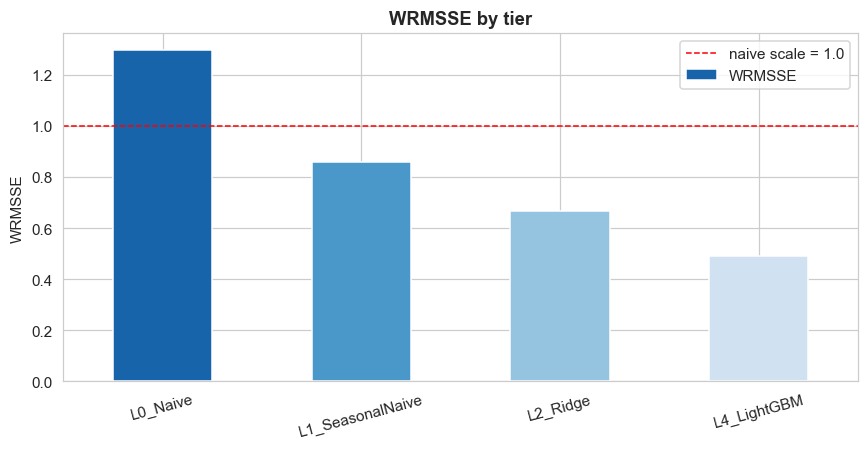

In [8]:
metrics_df = pd.DataFrame(results).T[["WRMSSE","WAPE","RMSE","BIAS"]]
display(metrics_df.round(4))
fig, ax = plt.subplots(figsize=(8,4.2))
metrics_df["WRMSSE"].plot(kind="bar", color=sns.color_palette("Blues_r", len(metrics_df)),
                          edgecolor="white", ax=ax)
ax.axhline(1.0, color="red", ls="--", lw=1, label="naive scale = 1.0")
ax.set_ylabel("WRMSSE"); ax.set_title("WRMSSE by tier", fontweight="bold")
ax.legend(); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

**FVA ladder** — marginal value each tier adds over the previous one; a negative bar means the extra complexity hurt.

,WRMSSE,FVA_vs_prev,FVA_vs_naive
L0_Naive,1.2977,NaN,0.0000
L1_SeasonalNaive,0.8588,0.4389,0.4389
L2_Ridge,0.6688,0.1900,0.6289
L4_LightGBM,0.4925,0.1763,0.8052


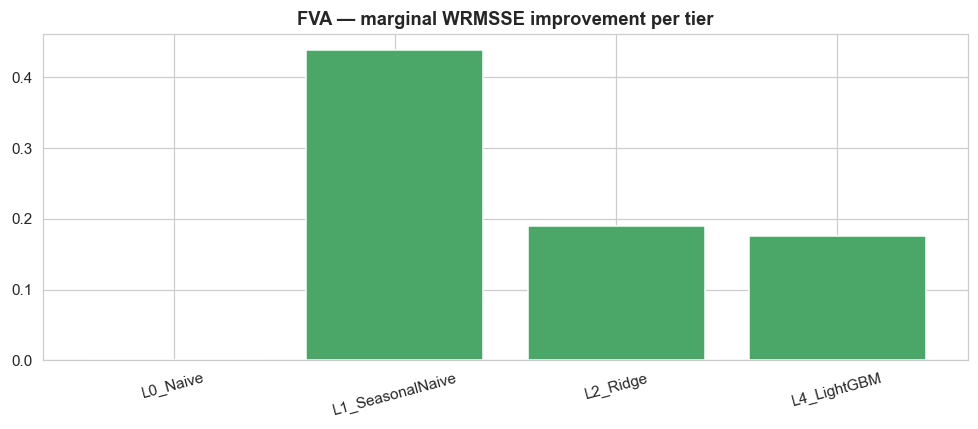

In [9]:
order = [m for m in ["L0_Naive","L1_SeasonalNaive","L2_Ridge","L4_LightGBM"] if m in metrics_df.index]
fva = metrics_df.loc[order, ["WRMSSE"]].copy()
fva["FVA_vs_prev"] = -fva["WRMSSE"].diff()
fva["FVA_vs_naive"] = fva.loc[order[0],"WRMSSE"] - fva["WRMSSE"]
display(fva.round(4))
colors = ["grey" if pd.isna(x) or x==0 else ("#4BA767" if x>0 else "#C8102E") for x in fva["FVA_vs_prev"]]
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(range(len(fva)), fva["FVA_vs_prev"].fillna(0), color=colors, edgecolor="white")
ax.axhline(0, color="black", lw=.5); ax.set_xticks(range(len(fva))); ax.set_xticklabels(fva.index, rotation=15)
ax.set_title("FVA — marginal WRMSSE improvement per tier", fontweight="bold"); plt.tight_layout(); plt.show()

Compute per-series RMSSE for the best model and export it (plus demand stats) for the segmentation notebook.

In [10]:
best = metrics_df["WRMSSE"].idxmin(); print("best tier:", best)
bp = preds[best]
rows=[]
for sid, g in bp.groupby("series_id"):
    ty = train[train["series_id"]==sid].sort_values("date")["units"].values
    vy = valid[valid["series_id"]==sid].sort_values("date")
    yhat = g.sort_values("date")["pred"].values
    rows.append({"series_id":sid, "rmsse":M.rmsse(ty, vy["units"].values, yhat),
                 "wape":M.wape(vy["units"].values, yhat)})
series_scores = pd.DataFrame(rows)
series_scores.to_parquet(ROOT/"data"/"series_scores.parquet", index=False)
bp.rename(columns={"pred":"forecast"}).to_parquet(ROOT/"data"/"baseline_forecast.parquet", index=False)
print("saved series_scores + baseline_forecast | mean RMSSE:", round(series_scores["rmsse"].mean(),3))
series_scores.head(3)

best tier: L4_LightGBM
saved series_scores + baseline_forecast | mean RMSSE: 0.763


,series_id,rmsse,wape
0,FOODS_1_001--CA_2,0.515545,1.493398
1,FOODS_1_001--CA_3,0.502080,0.997534
2,FOODS_1_003--CA_1,0.655377,1.258194
